# Algorithm Design — KNN Variants for Class Imbalance

This notebook is the theoretical companion to the project. It derives every algorithm from first
principles, explains all design decisions, and documents open research directions.

**Reader:** this is written as a reference document, not a tutorial. Familiarity with basic
probability and KNN classification is assumed. Each section is self-contained.

**Theory**

1. Problem statement and the journey to KNNFairRank
2. KNNFairRank — full derivation from first principles
3. Development history — from a single fair vote to the multi-rank scheme
4. Where the Poisson approximation breaks — failure modes of v3
5. Modification A — local imbalance ratio (dropped)
6. Modification B — magnitude-aware votes
7. Modification C — CV-tuned exponent α (headline variant)
8. Modification D — confidence-based per-query fallback (open)
9. Modification E — direct density-ratio formulation (open)
10. KNNAdaptiveTopo — persistent homology case classifier
11. Beyond FairRank — open directions (topology, clustering)

**Implementation Reference**

12. Implementation overview — class hierarchy and design principles
13. KNNBase — the lazy learner skeleton
14. KNNClassifier and KNNClassifierFast
15. KNNOptK — data-driven k selection
16. KNNFairRank — implementation walkthrough
17. KNNFairRankMagnitude — Modification B implementation
18. KNNFairRankCV — Modification C implementation


---
## 1. Problem Statement and the Journey to KNNFairRank

### 1.1 The setting

We study binary classification with class imbalance. Training data consists of $N$ points
$(x_i, y_i)$ where $y_i \in \{0, 1\}$, with class counts $N_\text{maj}$ (majority, label 0)
and $N_\text{min}$ (minority, label 1), and imbalance ratio:

$$r = \frac{N_\text{maj}}{N_\text{min}} \gg 1$$

Standard KNN classifies a query point $x$ by a majority vote over its $k$ nearest training
neighbours. Under class imbalance this vote is systematically biased toward the majority class —
not because $x$ is geometrically close to the majority, but because majority points are simply
more numerous and therefore tend to dominate any neighbourhood.

### 1.2 Two levels of bias

**Surface bias (k-selection).** With large $k$ the neighbourhood swells and is overwhelmed by
majority points. The natural response is to shrink $k$ — and `KNNOptK` does this via inner
cross-validation, selecting the globally optimal $k$ for each dataset. This helps: inner CV
selects $k=1$ in ≈62% of folds in our benchmark, confirming that the optimal global response
is maximal locality. But performance still degrades with IR even at $k=1$, which points to a
deeper problem.

**Structural bias (rank comparison).** Even with $k=1$, standard KNN makes a fundamentally
unfair comparison: it asks whether the *closest minority* neighbour is closer than the *closest
majority* neighbour. With $N_\text{maj} \gg N_\text{min}$, majority points are much denser
in space, so their closest representative is statistically expected to be closer to any query
point — not because of geometry, but because of sampling density. Standard KNN conflates
geometric proximity with class density, and this conflation persists no matter how small $k$ is.

This is the core problem KNNFairRank addresses. Section 2 derives the fix rigorously; the
rest of this section retraces the path that led to it, since understanding the dead ends makes
the fair-rank insight feel inevitable.

### 1.3 The journey to KNNFairRank

#### First direction: pick a better global k

The simplest reaction to surface bias is to blame the choice of $k$. With a large $k$ the
neighbourhood swells and gets flooded with majority points simply because there are more of
them. The first attempt is therefore `KNNOptK`: select $k$ by cross-validation to find the
value that works best across the dataset as a whole. It helps — $k=1$ is chosen in ~62% of
folds — but the IR-vs-performance scatter (phase 1 §3.1) shows performance still degrades
with IR. A globally optimal $k$ is not enough.

#### Second direction: adapt k per query point

If a *global* $k$ is too coarse, perhaps $k$ should depend on the local structure around each
query point. We explored this with `KNNAdaptiveTopo` (persistent homology), as well as
entropy- and eigenvalue-based variants. These do beat `KNNOptK` modestly, but the gap to the
fair-rank family is large — which suggests local $k$ adaptation, while helpful, is not the
right frame.

#### The structural insight: the problem is not k

The reason neither a globally optimal nor a locally adaptive $k$ fully solves the problem is
that the issue is not *how many* neighbours we look at — it is *how we compare* the two
classes once we have the neighbours. Even with $k=1$ (the most local possible choice),
standard KNN is making a fundamentally unfair comparison.

To see why, we need to be precise about what "rank" means here.

**What rank means.** When KNN classifies a query point $x$, it computes the distance from
$x$ to every training point and sorts them from closest to furthest — separately for each
class:

- **Minority rank 1** — the single closest minority training point to $x$; distance $d_1^\text{min}(x)$
- **Minority rank 2** — the second closest minority training point; distance $d_2^\text{min}(x)$
- **Majority rank 1** — the single closest majority training point; distance $d_1^\text{maj}(x)$
- **Majority rank 2** — the second closest majority training point

Rank $k$ is simply position $k$ in the distance-sorted list for that class.

**The unfair comparison.** Standard KNN with $k=1$ asks: *is the closest minority point closer
than the closest majority point?* — i.e. does $d_1^\text{min}(x) < d_1^\text{maj}(x)$? This
is **minority rank-1 vs majority rank-1**, which looks symmetric but is not. Majority training
points are denser in space because there are simply more of them spread across the same region.
So majority rank-1 tends to be close to any query point by sheer density, while minority rank-1
tends to be further away for the same reason. No matter how well we adapt $k$, as long as we
compare the same rank across both classes we are comparing different things.

**The fix in one line.** A fair comparison would pair minority rank-1 against the majority
rank whose *expected* distance equals minority rank-1's expected distance. That majority rank
turns out to be exactly $r$ — the imbalance ratio. So instead of asking "is the closest
minority point closer than the **1st** closest majority point?", we ask "is the closest
minority point closer than the **$r$-th** closest majority point?". Section 2 derives this
result rigorously from a Poisson model and §2.5 extends it to multiple votes for variance
reduction.


---
## 2. KNNFairRank — Full Derivation from First Principles

### 2.1 The rank concept

When classifying query point $x$, sort all training points of each class by distance to $x$
separately. Define:

- $d_k^\text{min}(x)$ — distance from $x$ to the $k$-th nearest **minority** training point
- $d_k^\text{maj}(x)$ — distance from $x$ to the $k$-th nearest **majority** training point

"Rank $k$" simply means position $k$ in that sorted list. Rank 1 is the closest, rank 2 the
second closest, and so on. Standard KNN with $k=1$ implicitly compares rank-1 minority against
rank-1 majority and predicts the class whose rank-1 point is closer.

### 2.2 Statistical model of nearest-neighbour distances

Assume training points of class $c$ are drawn from a spatial distribution with local density
$\lambda_c$ (points per unit volume) in a $d$-dimensional feature space. Under a homogeneous
Poisson process approximation, the expected number of class-$c$ points inside a ball of radius
$\rho$ centred at $x$ is:

$$\mathbb{E}[\text{count inside ball}] = \lambda_c \cdot V_d \cdot \rho^d$$

where $V_d = \pi^{d/2} / \Gamma(d/2 + 1)$ is the volume of the unit $d$-ball. The
$k$-th nearest neighbour distance is the smallest $\rho$ such that the expected count reaches
$k$, giving:

$$\mathbb{E}[d_k^c(x)] \propto \left(\frac{k}{\lambda_c}\right)^{1/d}$$

This is the key scaling law. Two observations follow immediately:

1. **Density effect:** for fixed $k$, a denser class ($\lambda_c$ large) has smaller expected
   nearest-neighbour distances. Majority points are denser ($\lambda_\text{maj} > \lambda_\text{min}$)
   so $\mathbb{E}[d_1^\text{maj}] < \mathbb{E}[d_1^\text{min}]$ regardless of $x$.

2. **Rank effect:** increasing $k$ increases the expected distance as $k^{1/d}$.

### 2.3 Quantifying the unfair comparison

Under balanced class priors, $\lambda_\text{maj}/\lambda_\text{min} = N_\text{maj}/N_\text{min} = r$.
Comparing both classes at rank 1:

$$\frac{\mathbb{E}[d_1^\text{min}(x)]}{\mathbb{E}[d_1^\text{maj}(x)]}
= \frac{(1/\lambda_\text{min})^{1/d}}{(1/\lambda_\text{maj})^{1/d}}
= \left(\frac{\lambda_\text{maj}}{\lambda_\text{min}}\right)^{1/d}
= r^{1/d}$$

For $r = 10$ in $d = 2$ dimensions: $r^{1/d} = \sqrt{10} \approx 3.16$. The nearest minority
neighbour is expected to be **3× further away** than the nearest majority neighbour, purely due to
density. This bias grows as $r$ increases and shrinks (but does not vanish) as $d$ increases.

### 2.4 Deriving the fair majority rank

A natural first guess is to use this distance ratio as the rank correction itself: if minority
distances are inflated by a factor of $r^{1/d}$, advance the majority comparison by the same
factor and set $k_\text{eff} = r^{1/d}$. This is what our v1/v2 prototypes did, and it is
wrong. The mistake is conflating ranks with distances: the scaling law shows rank enters
distance space through a $k^{1/d}$ factor, so to *cancel* a distance factor of $r^{1/d}$ the
*rank* factor needs to be $r$, not $r^{1/d}$. The derivation below makes this precise.

A fair comparison requires both sides to have the same expected distance under the null hypothesis
that $x$ lies on the decision boundary (where both classes are equally likely). We want the
majority rank $k_\text{eff}$ such that:

$$\mathbb{E}[d_1^\text{min}(x)] = \mathbb{E}[d_{k_\text{eff}}^\text{maj}(x)]$$

Substituting the scaling law:

$$\left(\frac{1}{\lambda_\text{min}}\right)^{1/d} = \left(\frac{k_\text{eff}}{\lambda_\text{maj}}\right)^{1/d}$$

Raising both sides to the power $d$ (eliminating the exponent):

$$\frac{1}{\lambda_\text{min}} = \frac{k_\text{eff}}{\lambda_\text{maj}}$$

$$\boxed{k_\text{eff} = \frac{\lambda_\text{maj}}{\lambda_\text{min}} = \frac{N_\text{maj}}{N_\text{min}} = r}$$

The $d$-th power eliminated the $1/d$ exponent — the fair rank is $r$, not $r^{1/d}$. The
distance ratio $r^{1/d}$ is the *symptom* of the bias; the rank correction $r$ is the *cure*.

**Decision rule.** KNNFairRank predicts minority iff:

$$d_1^\text{min}(x) < d_r^\text{maj}(x)$$

i.e., the closest minority neighbour is closer than the $r$-th closest majority neighbour.

### 2.5 Multi-rank voting — reducing variance

A single comparison (rank-1 minority vs rank-$r$ majority) is noisy: it depends on whichever
single minority point and single majority point happen to be at those positions, which fluctuates
across query points. To reduce variance, KNNFairRank aggregates multiple independent fair
comparisons.

The same fairness argument scales to higher ranks: if rank-1 minority is fairly compared against
majority rank $r$, then rank-$i$ minority is fairly compared against majority rank $i \cdot r$:

$$\mathbb{E}[d_i^\text{min}(x)] = \left(\frac{i}{\lambda_\text{min}}\right)^{1/d}
= \left(\frac{i \cdot r}{\lambda_\text{maj}}\right)^{1/d}
= \mathbb{E}[d_{i \cdot r}^\text{maj}(x)]$$

For each vote $i = 1, 2, \ldots, n_\text{votes}$, cast:

$$\text{vote}_i =
\begin{cases}
+1 & \text{if } d_i^\text{min}(x) < d_{i \cdot r}^\text{maj}(x) \quad (\text{minority wins}) \\
-1 & \text{otherwise} \quad (\text{majority wins})
\end{cases}$$

Final prediction: minority iff $\sum_{i=1}^{n_\text{votes}} \text{vote}_i > 0$.

Each vote is an independent fair comparison by the same Poisson argument. Aggregating $n_\text{votes}$
comparisons dramatically reduces the sensitivity to any single lucky or unlucky point placement.
In our implementation $n_\text{votes} = 5$.

### 2.6 What the algorithm needs at inference time

For a query point $x$:
1. Compute distances to all training points
2. Sort minority distances → $d_1^\text{min} \leq d_2^\text{min} \leq \ldots$
3. Sort majority distances → $d_1^\text{maj} \leq d_2^\text{maj} \leq \ldots$
4. Compute $r = N_\text{maj}/N_\text{min}$ (stored from training)
5. For $i = 1, \ldots, n_\text{votes}$: compare $d_i^\text{min}$ vs $d_{\lfloor i \cdot r \rfloor}^\text{maj}$
6. Predict minority iff majority of votes favour minority

Note: no fitting is required beyond storing $N_\text{maj}$, $N_\text{min}$, and the training
points. KNNFairRank is a lazy learner like standard KNN.


---
## 3. Development History — From a Single Fair Vote to the Multi-Rank Scheme

The current algorithm (v3) is the third iteration. The previous two are not failures to
catalogue but a useful warm-up: they isolate the two ingredients of the final scheme — the
fair rank correction and the multi-rank averaging — and show what each one contributes on its
own.

### 3.1 v1 — a single fair vote

v1 was the simplest possible incarnation of the fair-rank idea: cast exactly one comparison,
$d_1^\text{min}(x) < d_{k_\text{eff}}^\text{maj}(x)$, and predict minority iff that single
comparison favours minority. The structural problem with v1 is not the single-vote part — that
becomes naturally noisy and §2.5 explains how to fix it. The problem with v1 was its choice of
$k_\text{eff}$: it used $r^{1/d}$, the *distance* ratio, where it should have used $r$, the
*rank* correction. §2.4 walks through why those two are different.

### 3.2 v2 — multiple votes with the wrong correction

v2 kept v1's $k_\text{eff} = r^{1/d}$ but added the multi-rank voting machinery from §2.5.
This is informative: it shows that aggregating votes does not rescue a wrong correction.
Whatever stability multi-vote averaging buys, it cannot undo a systematic under-correction in
the comparison rank — at high IR the under-correction is a factor of $r^{1 - 1/d}$, which
grows with $r$ and is severe in the low-dimensional tabular regime where most of our datasets
live.

### 3.3 v3 — both ingredients, correct

v3 combines the correct $k_\text{eff} = r$ (§2.4) with the multi-rank voting scheme (§2.5).
The two ingredients are independent and each contributes: the fair rank fixes the systematic
bias, the multi-vote averaging reduces variance around it. Removing either one degrades v3 in a
predictable way — to v1 (one fair comparison, noisy) or to v2 (many comparisons, biased).


---
## 3.5. Optimal Vote Count — Theory

The multi-vote scheme raises an immediate question: how many votes is enough, and is there a
point past which adding more votes hurts? This section works out the answer from first
principles.

---

### 3.5.1 All individual votes are unbiased

The rank correction $k_\text{eff} = r$ was motivated in §2 for a single comparison at rank 1.
It is exact in expectation for *every* vote index $i$, not just the first.

By the Poisson-process order-statistics formula:

$$\mathbb{E}[d_k^c] \propto \left(\frac{k}{N_c}\right)^{1/d}$$

Vote $i$ compares $d_i^\text{min}$ against $d_{i \cdot k_\text{eff}}^\text{maj}$. Setting
$k_\text{eff} = r = N_\text{maj}/N_\text{min}$:

$$\mathbb{E}\!\left[d_{i \cdot k_\text{eff}}^\text{maj}\right]
  \propto \left(\frac{i \cdot r}{N_\text{maj}}\right)^{1/d}
  = \left(\frac{i}{N_\text{min}}\right)^{1/d}
  = \mathbb{E}[d_i^\text{min}] \qquad \forall\, i = 1, \ldots, N_\text{min}$$

**The rank correction is self-consistent at every rank.** Adding more votes cannot introduce a
systematic bias — it can only affect variance and correlation structure.

---

### 3.5.2 Votes are positively correlated — the effective-information ceiling

Even though each vote is individually valid, votes are not independent. $d_i^\text{min}$ and
$d_j^\text{min}$ both come from the same sorted distance list: if the query is geometrically
close to the minority cloud, every vote tends to say "minority" simultaneously. Define the
average pairwise inter-vote correlation:

$$\bar{\rho}
  = \frac{1}{\binom{n}{2}} \sum_{i < j} \operatorname{Corr}(V_i,\, V_j),
  \qquad
  V_i = \mathbf{1}\!\left[d_i^\text{min} < d_{i \cdot k_\text{eff}}^\text{maj}\right]$$

For correlated binary votes the **effective number of independent votes** is:

$$n_\text{eff}(n) = \frac{n}{1 + (n-1)\,\bar{\rho}}$$

As $n \to \infty$, $n_\text{eff} \to 1/\bar{\rho}$. Information **saturates** at $1/\bar{\rho}$
regardless of how many votes you cast. For Poisson nearest-neighbour order statistics, adjacent
ranks correlate at $\bar{\rho} \approx 0.2$–$0.4$, so $n_\text{eff,max} \approx 2.5$–$5$.

---

### 3.5.3 Signal degrades with rank

Define the **signal strength** of vote $i$ as:

$$s_i = P\!\left(V_i = \text{minority} \;\middle|\; x \text{ is truly minority}\right) - 0.5 \;\geq 0$$

$s_1$ is the strongest: $d_1^\text{min}$ is the single closest minority point, capturing the
most local geometry. For larger $i$, $d_i^\text{min}$ comes from the $i$-th ring of the
minority cloud — progressively less representative of the query's immediate neighbourhood.
As $i \to \infty$, $s_i \to 0$.

The aggregate fraction $\hat{p}_n = \frac{1}{n}\sum_{i=1}^n V_i$ has expected value
$\frac{1}{n}\sum s_i + 0.5$. Because $s_i$ is decreasing, adding vote $n+1$ lowers the mean
signal of the aggregate once $s_{n+1} < \bar{s}_n$. Beyond the peak, each additional vote
dilutes rather than refines the aggregate.

---

### 3.5.4 Optimal vote count

Two independent upper bounds apply simultaneously:

**Effective-information ceiling** (from §3.5.2):

$$n_\text{votes} \lesssim \frac{1}{\bar{\rho}} \approx 3\text{–}5$$

**Locality principle** (from §3.5.3): the $i$-th nearest minority neighbour lies at distance
$\sim (i/N_\text{min})^{1/d}$. The stable KNN neighbourhood spans roughly
$k^* \sim \sqrt{N_\text{train}}$ points (the empirical optimum under KNNOptK). The comparison
stays local only for $i \lesssim \sqrt{N_\text{min}}$:

$$n_\text{votes} \lesssim \sqrt{N_\text{min}}$$

Taking the binding constraint:

$$\boxed{n^* \approx \min\!\left(\frac{1}{\bar{\rho}},\; \sqrt{N_\text{min}}\right)}$$

For most benchmark datasets $N_\text{min} \geq 20$, so $\sqrt{N_\text{min}} \geq 4.5$ and the
correlation ceiling ($\approx$3–5) dominates. **The default of 5 sits at the theoretical
optimum for the bulk of the benchmark suite.**

| $N_\text{min}$ | $\sqrt{N_\text{min}}$ | $1/\bar{\rho}$ (typical) | $n^*$ |
|:---:|:---:|:---:|:---:|
| 10 | 3.2 | 3–5 | **3** |
| 25 | 5.0 | 3–5 | **3–5** |
| 50 | 7.1 | 3–5 | **3–5** |
| 100 | 10 | 3–5 | **3–5** |
| 400 | 20 | 3–5 | **3–5** |

---

### 3.5.5 High-IR pathology

At large imbalance ratio $r$, vote $n$ reaches majority rank $n \cdot r$. For
$n_\text{votes} = 5$ and $r = 100$, vote 5 compares $d_5^\text{min}$ with $d_{500}^\text{maj}$
— the 500th nearest majority point, well outside any local neighbourhood. A tighter locality
constraint for high-IR datasets is:

$$n_\text{votes} \leq \left\lfloor \frac{\sqrt{N_\text{maj}}}{r} \right\rfloor
  = \left\lfloor \frac{N_\text{min}}{\sqrt{N_\text{maj}}} \right\rfloor$$

For $N_\text{min} = 20$, $N_\text{maj} = 2000$ ($r = 100$): bound
$= \lfloor 20 / \sqrt{2000} \rfloor = 0$. Even a single vote reaches far into the majority
cloud in this extreme regime. In practice this is mitigated by `k_maj_cap` (§16), which
prevents the majority neighbourhood buffer from growing without bound — but it is worth knowing
that the *conceptual* quality of each comparison degrades steeply as $r$ grows.

---

### 3.5.6 Empirical findings — two regimes, not one

Running the sweep over the full benchmark (45 datasets, 5-fold CV) produces a
**bimodal** distribution of per-dataset optimal $n_\text{votes}$:

| $n_\text{votes}$ | Datasets at peak |
|:---:|:---:|
| 1 | 10 |
| 2 | 18 |
| 3 | 2 |
| 5 | 3 |
| 7 | 4 |
| 10 | 8 |

Two distinct regimes emerge with almost nothing in between:

- **Few-votes regime** ($n \in \{1, 2\}$, 28 datasets): small $N_\text{min}$ or
  tightly-clustered minorities where ranks 1–2 capture all useful local geometry.
  Consistent with the locality bound $n^* \lesssim \sqrt{N_\text{min}}$ being small.
- **Many-votes regime** ($n \in \{7, 10\}$, 12 datasets): larger or more diffuse
  minority clouds where the locality bound is not the binding constraint and
  additional votes genuinely reduce variance.

The fixed default $n_\text{votes} = 5$ falls in the dead zone between the two
clusters: only **7 / 45 datasets** are within 0.5% of optimal at $n=5$.

**Why does the aggregate G-mean still grow past $n=2$?**
Datasets in the few-votes regime *plateau* after their peak rather than declining —
extra votes carry near-zero signal, not negative signal, so they do not pull the
aggregate down. Datasets in the many-votes regime continue improving and push the
aggregate curve up. The net result is a monotonically increasing aggregate even
though most datasets peaked long before.

---

### 3.5.7 CV-selected vote count — `KNNFairRankOptVotes`

Since no fixed $n_\text{votes}$ covers both regimes, the natural fix is to select it
via inner CV, exactly as `KNNFairRankCV` selects $\alpha$.

**Why inner CV is cheap here:** the expensive step in each query is
`_per_class_distances` (the `cdist` call), which depends only on `k_min` and
`k_maj` — both set at `fit` time and independent of $n_\text{votes}$. Evaluating
different vote counts on pre-fitted neighbours amounts to array indexing into
already-sorted distances. The inner CV therefore pays only for extra `fit()` calls,
not extra distance computations — the same class of overhead as `KNNFairRankCV`.

**Implementation (`knn_fair_rank_opt_votes.py`):** selects $n_\text{votes}$ from the
grid $\{1, 2, 3, 5, 7, 10\}$ via 3-fold stratified inner CV optimising G-mean.
The neighbourhood is sized for the largest grid candidate so all values can be
evaluated within a single outer `fit()`. The selected count is stored in
`best_n_votes_` for inspection.

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Loaded 49 datasets.
CPUs: 16  |  N_JOBS=4
  [ 2/49] dataset_1004_synthetic_control  (n_min=100)
  [ 3/49] dataset_1014_analcatdata_dmft  (n_min=155)
  [ 4/49] dataset_1016_vowel  (n_min=90)
  [ 5/49] dataset_1020_mfeat-karhunen  (n_min=200)
  [ 6/49] dataset_1000_hypothyroid  (n_min=291)
  [ 7/49] dataset_1021_page-blocks  (n_min=560)
  [ 8/49] dataset_1023_soybean  (n_min=92)
  [10/49] dataset_1022_mfeat-pixel  (n_min=200)
  [11/49] dataset_1049_pc4  (n_min=178)
  [12/49] dataset_1050_pc3  (n_min=160)
  [14/49] dataset_1061_ar4  (n_min=20)
  [15/49] dataset_1064_ar6  (n_min=15)
  [16/49] dataset_1065_kc3  (n_min=43)
  [17/49] dataset_311_oil_spill  (n_min=41)
  [18/49] dataset_312_scene  (n_min=431)
  [19/49] dataset_316_yeast_ml8  (n_min=34)
  [20/49] dataset_38_sick  (n_min=231)
  [21/49] dataset_450_analcatdata_lawsuit  (n_min=19)
  [22/49] dataset_463_backache  (n_min=25)
  [23/49] dataset_757_meta  (n_min=54)
  [24/49] dataset_764_analcatdata_apnea3  (n_min=55)
  [25/49] dataset_

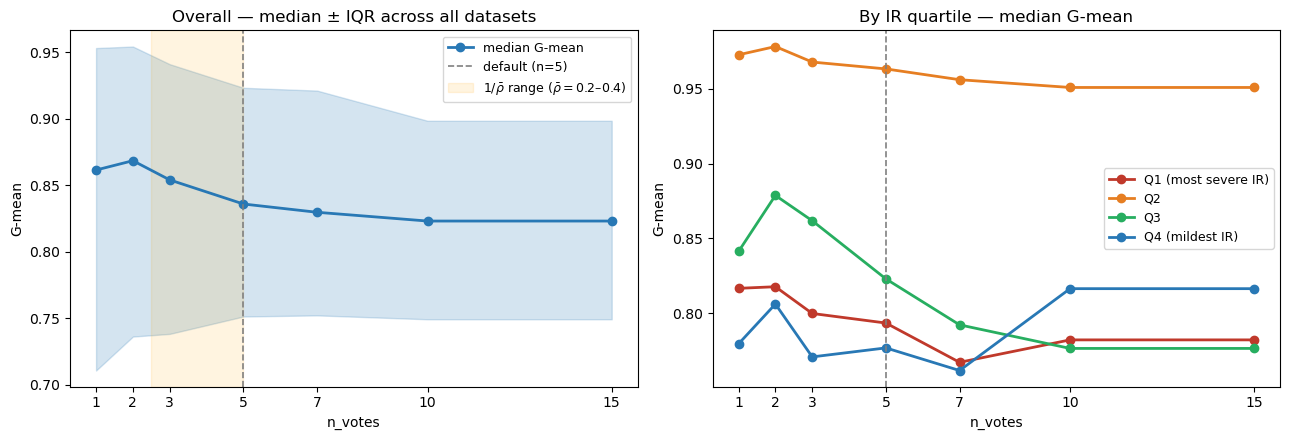

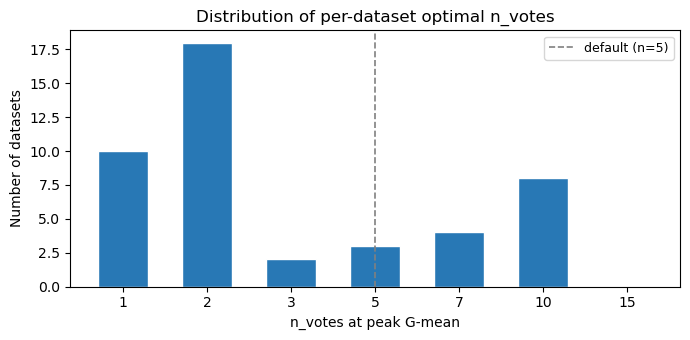


Per-dataset peak n_votes:
1     10
2     18
3      2
5      3
7      4
10     8
15     0

Datasets where n=5 is optimal or within 0.5% of optimal: 7 / 45


In [1]:
import sys
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedKFold

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features, standardise
from src.algorithms.knn_fair_rank import KNNFairRank
from src.evaluation.metrics import geometric_mean

# ─── Configuration ────────────────────────────────────────────────────────────
N_VOTES_GRID = [1, 2, 3, 5, 7, 10, 15]
N_FOLDS      = 5
MIN_N_MIN    = 10      # skip datasets too small for 5-fold CV
SEED         = 42
N_JOBS       = 4       # dataset-level parallelism; set to 1 to disable
CACHE        = project_root / "results" / "tables" / "nvotes_sweep.csv"

# ─── Worker: one dataset, all n_votes ─────────────────────────────────────────
def _sweep_dataset(ds, n_votes_grid, n_folds, seed, min_n_min):
    import warnings, numpy as np
    from src.data.preprocessing import binarise_labels, remove_constant_features, standardise
    from src.algorithms.knn_fair_rank import KNNFairRank
    from src.evaluation.metrics import geometric_mean
    from sklearn.model_selection import StratifiedKFold

    X = remove_constant_features(ds.X)
    y = binarise_labels(ds.y)
    n_min = int(y.sum())
    if n_min < min_n_min:
        return []

    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    records = []
    for nv in n_votes_grid:
        fold_scores = []
        for tr, va in cv.split(X, y):
            X_tr, X_va = standardise(X[tr], X[va])
            clf = KNNFairRank(n_votes=nv)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                clf.fit(X_tr, y[tr])
                fold_scores.append(geometric_mean(y[va], clf.predict(X_va)))
        records.append({
            "dataset":  ds.name,
            "n_min":    n_min,
            "ir_ratio": ds.imbalance_ratio,
            "n_votes":  nv,
            "gmean":    float(np.mean(fold_scores)),
        })
    return records

# ─── Load datasets ────────────────────────────────────────────────────────────
datasets = load_all_datasets()
print(f"Loaded {len(datasets)} datasets.")

# ─── Run or resume from cache ─────────────────────────────────────────────────
if CACHE.exists():
    df = pd.read_csv(CACHE)
    print(f"Loaded from cache ({df['dataset'].nunique()} datasets, delete {CACHE.name} to re-run).")
else:
    _cpu = os.cpu_count() or 4
    print(f"CPUs: {_cpu}  |  N_JOBS={N_JOBS}")

    all_records = []
    gen = Parallel(n_jobs=N_JOBS, prefer="threads", return_as="generator_unordered")(
        delayed(_sweep_dataset)(ds, N_VOTES_GRID, N_FOLDS, SEED, MIN_N_MIN)
        for ds in datasets
    )
    for i, records in enumerate(gen):
        if not records:
            continue
        all_records.extend(records)
        ds_name = records[0]["dataset"]
        n_min   = records[0]["n_min"]
        print(f"  [{i+1:>2}/{len(datasets)}] {ds_name}  (n_min={n_min})")

    df = pd.DataFrame(all_records)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CACHE, index=False)
    print(f"\nSaved to {CACHE.name}  ({df['dataset'].nunique()} datasets included).")

# ─── Figure 1: overall median G-mean ± IQR ───────────────────────────────────
agg = df.groupby("n_votes")["gmean"].agg(
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.fill_between(agg.index, agg["q25"], agg["q75"], alpha=0.2, color="#2878B5")
ax.plot(agg.index, agg["median"], "o-", color="#2878B5", lw=2, label="median G-mean")
ax.axvline(5, color="grey", lw=1.2, ls="--", label="default (n=5)")
ax.axvspan(1/0.4, 1/0.2, alpha=0.12, color="orange",
           label=r"$1/\bar{\rho}$ range ($\bar{\rho}=0.2$–$0.4$)")
ax.set_xlabel("n_votes")
ax.set_ylabel("G-mean")
ax.set_title("Overall — median ± IQR across all datasets")
ax.legend(fontsize=9)
ax.set_xticks(N_VOTES_GRID)

# ─── Figure 2: by IR quartile ────────────────────────────────────────────────
df["ir_quartile"] = pd.qcut(
    df["ir_ratio"], q=4,
    labels=["Q1 (most severe IR)", "Q2", "Q3", "Q4 (mildest IR)"]
)
colors = ["#C0392B", "#E67E22", "#27AE60", "#2878B5"]

ax = axes[1]
for label, color in zip(["Q1 (most severe IR)", "Q2", "Q3", "Q4 (mildest IR)"], colors):
    sub = df[df["ir_quartile"] == label].groupby("n_votes")["gmean"].median()
    ax.plot(sub.index, sub.values, "o-", color=color, lw=2, label=label)
ax.axvline(5, color="grey", lw=1.2, ls="--")
ax.set_xlabel("n_votes")
ax.set_ylabel("G-mean")
ax.set_title("By IR quartile — median G-mean")
ax.legend(fontsize=9)
ax.set_xticks(N_VOTES_GRID)

plt.tight_layout()
plt.show()

# ─── Figure 3: distribution of per-dataset optimal n_votes ───────────────────
pivot   = df.pivot_table(index="dataset", columns="n_votes", values="gmean")
peak_nv = pivot.idxmax(axis=1)
counts  = peak_nv.value_counts().reindex(N_VOTES_GRID, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar([str(v) for v in counts.index], counts.values,
       color="#2878B5", edgecolor="white", width=0.6)
ax.axvline(counts.index.tolist().index(5), color="grey", lw=1.2, ls="--",
           label="default (n=5)")
ax.set_xlabel("n_votes at peak G-mean")
ax.set_ylabel("Number of datasets")
ax.set_title("Distribution of per-dataset optimal n_votes")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ─── Summary ─────────────────────────────────────────────────────────────────
print("\nPer-dataset peak n_votes:")
print(counts.to_string())
best  = pivot.max(axis=1)
at5   = pivot[5]
close = ((best - at5) / best.clip(lower=1e-9) < 0.005).sum()
print(f"\nDatasets where n=5 is optimal or within 0.5% of optimal: {close} / {len(pivot)}")

---
## 4. Where the Poisson Approximation Breaks — Failure Modes of v3

The fair-rank derivation in §2 assumes training points are drawn from a homogeneous Poisson
process: uniform spatial density, independence, no clustering. Real datasets only ever
*approximately* satisfy this. The interesting question is not whether the assumption holds (it
doesn't) but where it breaks and how each break affects v3's predictions.

Three of the four failure modes below — F1, F2, F4 — are different manifestations of the same
underlying issue: the Poisson-uniform model is only an approximation. F3 is genuinely separate
and concerns how votes are *combined* once they have been cast. Together they motivate
Modifications A–E in §§5–9.

### 4.1 F1 — Local density is non-uniform (Poisson approximation, version 1)

The Poisson-uniform model predicts class-$c$ density is constant: $\lambda_c$ everywhere.
Real minority classes typically cluster — there are pockets of high local minority density
separated by gaps with almost no minority points. Inside a cluster the local minority density
exceeds the global average; far from any cluster it falls well below.

Because v3 uses the *global* $r$ everywhere, the same correction is applied to query points in
both regimes. Near a minority cluster the correction over-shoots (local $r_\text{local} < r$);
far from any cluster it under-shoots. The error has opposite sign in the two regimes, which
shows up as high dataset-to-dataset variance in v3's performance.

### 4.2 F2 — Global $r$ is the wrong target locally (Poisson approximation, version 2)

F2 is the same kind of mismatch as F1 but on the majority side. Even when minority points
*are* roughly uniform, the majority class often is not — it has dense regions and sparse
regions of its own. Near a majority-dense region, $r_\text{local} > r$ and a stronger
correction is needed; near a majority-sparse region, less is needed. v3's single global
$k_\text{eff}$ cannot adapt to either.

### 4.3 F3 — Binary votes discard margin

This failure mode does not depend on the Poisson approximation at all — it concerns how votes
are aggregated. The binary vote $\text{vote}_i \in \{+1, -1\}$ treats a comparison where
$d_i^\text{min} = 0.001$ and $d_{ir}^\text{maj} = 100$ identically to one where
$d_i^\text{min} = 0.49$ and $d_{ir}^\text{maj} = 0.51$. The former is overwhelming evidence
for minority; the latter is a coin flip. Aggregating binary votes throws away that distinction,
so the resulting vote fraction is a poor proxy for classification confidence — which matters
for `predict_proba` and threshold tuning even when it does not change hard-label decisions.

### 4.4 F4 — No dampening when the approximation fails globally (Poisson approximation, version 3)

F4 is the third Poisson-approximation manifestation. On datasets where the Poisson-uniform
assumption is *globally* violated — for example, a heavily clustered minority class in a
low-dimensional space — v3 may systematically over-correct everywhere. There is no parameter
to dial the correction down. The only tool v3 has is its derived value $k_\text{eff} = r$,
which is correct under the assumption but not when the assumption is wrong.

The effect is that on hostile datasets v3's G-mean can drop below SMOTE+KNN or even KNNOptK.
What is missing is an escape hatch — a way to interpolate between "trust the theory fully"
and "trust the data more than the theory".


---
## 5. Modification A — Local Imbalance Ratio (Dropped)

**Targets:** F1, F2

### 5.1 Idea

Replace the global ratio $r = N_\text{maj}/N_\text{min}$ with a per-query local estimate
$r_\text{local}(x)$. For each query point, look at a reference window of $K_\text{ref}$
nearest neighbours (from both classes combined) and compute the local ratio from the class
counts within that window:

$$r_\text{local}(x) = \frac{\text{count of majority in } K_\text{ref}\text{-window}}{\text{count of minority in } K_\text{ref}\text{-window}}$$

Then use $k_\text{eff}(x) = r_\text{local}(x)$ for this query.

**Intuition.** Near a minority cluster, the $K_\text{ref}$ window would contain many minority
points, giving $r_\text{local} < r$ and therefore a smaller correction. Near a sparse minority
region, $r_\text{local} > r$ and a stronger correction is applied. This adapts the correction
to the local class distribution as required by F1/F2.

### 5.2 Why it was dropped

The idea is appealing but collapses in the regime it is designed to help. When $N_\text{min}$
is small, the $K_\text{ref}$-window frequently contains **zero minority points**, making
$r_\text{local}$ undefined (division by zero). The only fix is to set a floor — but a floor
of 1 gives $r_\text{local} = K_\text{ref}$, which is an arbitrary large number unrelated to
the local geometry. A floor of $\epsilon > 0$ is similarly arbitrary.

The root cause is a fundamental sample-size restriction: to reliably estimate local class ratios
you need enough minority points in the window, but the whole problem is that minority points
are rare. The modification requires the very resource that imbalance denies.

**Formal condition for reliability.** For $r_\text{local}$ to have standard error less than
$\delta \cdot r_\text{local}$ (i.e. relative error below $\delta$), you need approximately:

$$n_\text{min}^\text{window} \geq \frac{1}{\delta^2 \cdot p_\text{min}^\text{window}}$$

where $p_\text{min}^\text{window}$ is the minority fraction in the window. At high IR,
$p_\text{min}^\text{window} \ll 1$, and the required count exceeds the total number of
minority points in the dataset. The modification is theoretically sound but practically infeasible
at the imbalance levels where it would matter most.

---
## 6. Modification B — Magnitude-Aware Votes

**Targets:** F3

### 6.1 The problem with binary votes

Standard v3 vote $i$:
$$\text{vote}_i = \begin{cases} +1 & d_i^\text{min} < d_{ir}^\text{maj} \\ -1 & \text{otherwise} \end{cases}$$

This is a hard threshold. The signed distance ratio $d_{ir}^\text{maj} / d_i^\text{min}$ — which
carries genuine information about how strongly minority-like or majority-like the query is —
is discarded.

### 6.2 Continuous score

Replace the binary vote with a soft score that preserves the distance ratio:

$$s_i = \frac{d_{ir}^\text{maj}(x)}{d_i^\text{min}(x) + d_{ir}^\text{maj}(x)} \in (0, 1)$$

**Interpretation:**
- $s_i = 0.5$ — the two distances are equal (exactly at the fair comparison boundary)
- $s_i \to 1$ — minority is much closer than majority at rank $ir$ (strong minority evidence)
- $s_i \to 0$ — majority is much closer (strong majority evidence)

The final decision: predict minority iff $\bar{s} = \frac{1}{n_\text{votes}} \sum_{i=1}^{n_\text{votes}} s_i > 0.5$.

This is equivalent to a thresholded mean of the soft votes. Unlike binary votes, a single
overwhelmingly clear comparison (large $s_i$) can outweigh several marginal comparisons in the
other direction.

### 6.3 Theoretical properties

The score $s_i$ can be interpreted as a probabilistic vote. If the $i$-th comparison distance
ratio $d_{ir}^\text{maj} / d_i^\text{min}$ follows a log-normal distribution under the Poisson
model, $s_i$ approximates the posterior probability $P(\text{minority} \mid \text{distances at rank } i)$.
This is not a rigorous derivation but motivates the form.

### 6.4 What it fixes and what it does not

**F3 (addressed).** The score preserves the margin of each comparison. A near-tie contributes
$s_i \approx 0.5$ (weak evidence) and a blowout contributes $s_i \approx 1$ (strong evidence).

**F1, F2 (not addressed).** The comparison ranks still use global $r$. The same
Poisson-uniform assumption applies.

**F4 (not addressed).** There is no mechanism to reduce the correction globally.

### 6.5 Empirical result

On the current benchmark `KNNFairRankMagnitude` is the **per-metric leader on ROC AUC**
(0.880 vs v3's 0.864 — a clear ≈+1.6 point gain, the largest of any variant on that metric).
On G-mean it is essentially tied with v3 (0.815 vs 0.820, within fold-level noise). The
asymmetric pattern matches the theory: the soft score changes how *confident* the model is
about each prediction (which directly improves ranking metrics like ROC AUC) without changing
the *direction* of the hard decision at the default 0.5 threshold (which is what G-mean and F1
measure).

**Open follow-up: combine B with C.** Modifications B and C are independent — B replaces the
binary vote with a soft score, C adds a CV-tuned exponent $\alpha$ to dial the correction
strength. We currently have neither variant alone (`KNNFairRankMagnitude` and
`KNNFairRankCV`) but no combined one. A `KNNFairRankMagnitudeCV` would inherit the soft-score
voting from B and the inner-CV α-selection from C; given that B already wins ROC AUC and C
already wins G-mean, the combination is the natural next experiment.


---
## 7. Modification C — CV-Tuned Exponent α (Headline Variant)

**Targets:** F4

### 7.1 Motivation

v3 applies the correction $k_\text{eff} = r$ with no way to reduce it on datasets where the
Poisson-uniform assumption is violated. We need a tunable dial between:
- $\alpha = 0$: $k_\text{eff} = r^0 = 1$ — no correction (standard 1-NN-style comparison)
- $\alpha = 1$: $k_\text{eff} = r^1 = r$ — full v3 correction

For $\alpha \in (0, 1)$: a partial correction that discounts the theoretical value. The
parameter $\alpha$ modulates how strongly we trust the Poisson-uniform assumption.

### 7.2 The exponent parameterisation

Define the effective majority rank as:

$$k_\text{eff} = \text{round}(r^\alpha), \quad \alpha \in [0, 1]$$

The voting scheme is identical to v3: for $i = 1, \ldots, n_\text{votes}$, compare
$d_i^\text{min}$ against $d_{i \cdot k_\text{eff}}^\text{maj}$.

**Why this parameterisation?** The exponent $\alpha$ acts on the rank in the same space as
the original theoretical derivation. $k_\text{eff} = r^\alpha$ is the correction that would
be theoretically correct if the data's effective intrinsic dimensionality were $1/\alpha$
rather than 1 — i.e., it interpolates naturally between no correction and full correction in a
dimensionally-motivated way.

### 7.3 Selecting α by inner cross-validation

For each training fold, perform an inner $3$-fold stratified CV over a small grid of candidate
$\alpha$ values, scored by G-mean (the primary metric). The $\alpha$ that maximises inner CV
G-mean is used for prediction on the outer test fold.

**Grid choice (current).** The grid we use is $\alpha \in \{0.25, 0.5, 0.75, 1.0\}$ —
four values spanning mild ($r^{0.25}$) to full ($r^1 = r$) correction. The endpoint
$\alpha = 1$ recovers v3 exactly, so when the Poisson-uniform assumption holds well the inner
CV can land on the theoretical value at no cost.

**Should $\alpha = 0$ be in the grid?** This is an open question. $\alpha = 0$ gives
$k_\text{eff} = 1$, which is rank-1-vs-rank-1 — the same comparison standard 1-NN makes
inside the FairRank scaffolding. We currently exclude it because it makes the algorithm
degenerate to "no fair-rank correction at all" on a fold where CV picks it; on the other hand,
on datasets where the Poisson approximation is so badly violated that any rank correction
hurts (a real possibility under F1/F2/F4), $\alpha = 0$ would let the algorithm gracefully
fall back to no correction instead of being forced to apply at least $r^{0.25}$. Adding
$\alpha = 0$ to the grid is a one-line change and the right experiment to run before
declaring §7's grid final.

### 7.4 v3 as a special case

When $\alpha = 1$, `KNNFairRankCV` reduces exactly to v3. When the Poisson-uniform assumption
holds well, inner CV should select $\alpha = 1$. The distribution of selected $\alpha$ values
across datasets is therefore diagnostic: if $\alpha = 1$ dominates, the assumption is
approximately valid; if lower values dominate, the assumption is frequently violated.

### 7.5 Addressing F1 and F2 indirectly

While $\alpha$ is still a global parameter per dataset (not per query), it partially addresses
F1 and F2 at the dataset level: if the minority class is highly clustered on a particular
dataset, the inner CV will tend to find that a smaller $\alpha$ (less aggressive correction)
produces better G-mean, effectively detecting and dampening the over-correction.

### 7.6 Empirical result

`KNNFairRankCV` achieves the **best average rank** across our benchmark, outperforming v3 in
rank stability if not always in headline metrics. Section 18 walks through the implementation
including the trick that lets the inner CV evaluate every $\alpha$ in a fold without re-fitting
the model.


---
## 8. Modification D — Confidence-Based Per-Query Fallback (Open Direction)

**Targets:** F4, partially F3

### 8.1 Idea

Modification C addresses F4 at the *dataset level* — it selects a global $\alpha$ that works
well on average across the dataset. But $\alpha$ may be correct on average yet wrong in specific
regions of the feature space (heterogeneous datasets). Modification D addresses F4 at the
*query-point level*.

When KNNFairRank's vote is close to the indifference point, the classifier is uncertain. In those
cases, defer to a reliable fallback (e.g. `KNNOptK`):

$$\hat{y}(x) = \begin{cases}
\hat{y}_\text{FairRank}(x) & \text{if } |\bar{s} - \tfrac{1}{2}| \geq \tau \\
\hat{y}_\text{fallback}(x) & \text{otherwise}
\end{cases}$$

where $\bar{s}$ is the mean vote score (from Modification B) or vote fraction (from v3), and
$\tau \in (0, \tfrac{1}{2})$ is a confidence threshold. When the score is close to 0.5
(ambiguous), the fallback takes over.

### 8.2 Implementation sketch

Wrap `KNNFairRank` in a thin meta-classifier that also holds a pre-fit `KNNOptK`. At predict
time: run FairRank, check the vote margin, and delegate per-query to the fallback if the margin
is below $\tau$.

### 8.3 Why it is lower priority after Modification C

D was originally motivated by the observation that FairRank's catastrophic failures concentrate
near the decision boundary — exactly the ambiguous region where $\bar{s} \approx 0.5$. But
once Modification C damps global over-correction via $\alpha$, most of those failures become
globally mitigated. D would then only add value on datasets where $\alpha$ is correct on
average but incorrect in specific pockets — a second-order effect.

**When D would still matter:**
- Datasets with strong spatial heterogeneity within a class (minority sub-groups with very
  different densities in different regions)
- Safety-critical settings where a hard worst-case guarantee relative to a baseline is required

### 8.4 Cost and risk

**Cost.** One extra hyperparameter ($\tau$), one extra model fit (the fallback), up to two
predict calls per query.

**Risk.** The algorithm becomes a conditional dispatcher, which breaks the "single principled
decision rule" property of v3. This makes it harder to analyse theoretically and harder to
explain.

---
## 9. Modification E — Direct Density-Ratio Formulation (Open Direction)

**Targets:** F1, F2

### 9.1 Idea

Rather than correcting the comparison rank as a proxy for density, estimate the class-conditional
local densities directly and apply Bayes' rule with balanced priors:

$$\hat{y}(x) = \text{minority} \iff \hat{p}(x \mid \text{min}) > \hat{p}(x \mid \text{maj})$$

The standard $k$-NN density estimator of class $c$ at query $x$ is:

$$\hat{p}(x \mid c) = \frac{k_c}{N_c \cdot V_d \cdot d_{k_c}^c(x)^d}$$

where $k_c$ is the number of class-$c$ neighbours used, $d_{k_c}^c(x)$ is the distance to the
$k_c$-th nearest class-$c$ neighbour, and $V_d$ is the volume of the unit $d$-ball. This
estimator captures local density variations: near a minority cluster, $d_{k_c}^\text{min}(x)$
is small and $\hat{p}(x \mid \text{min})$ is large.

### 9.2 v3 is a special case of E

Setting $k_\text{min} = 1$, $k_\text{maj} = k_\text{eff}$, and asking when
$\hat{p}(x \mid \text{min}) = \hat{p}(x \mid \text{maj})$ (the decision boundary):

$$\frac{1}{N_\text{min} \cdot d_1^\text{min}(x)^d} = \frac{k_\text{eff}}{N_\text{maj} \cdot d_{k_\text{eff}}^\text{maj}(x)^d}$$

At distance parity ($d_1^\text{min} = d_{k_\text{eff}}^\text{maj}$, the v3 decision
boundary) the distances cancel:

$$\frac{1}{N_\text{min}} = \frac{k_\text{eff}}{N_\text{maj}}
\implies k_\text{eff} = \frac{N_\text{maj}}{N_\text{min}} = r$$

**v3 is exactly Modification E with $k_\text{min} = 1$ and the distance-parity decision rule
under Poisson-uniform density.** Modification E is the general framework; v3 is the special
case where the local density estimate is replaced by the global class ratio.

### 9.3 What the generalisation buys

With $k_\text{min} > 1$, the density estimate for the minority class averages over more
neighbours, reducing noise. With $k_\text{maj}$ chosen jointly with $k_\text{min}$, the
optimal majority neighbourhood size adapts to local geometry rather than being forced to equal
$r \cdot k_\text{min}$.

More importantly, the full density estimate uses $d_{k_c}^c(x)^d$ rather than just comparing
two scalar distances. This captures local density variation (F1) without requiring a local ratio
estimate that collapses at small minority sample sizes (the failure of Modification A).

### 9.4 Implementation sketch

At predict time, for each query $x$:
1. Compute $d_{k_\text{min}}^\text{min}(x)$ and $d_{k_\text{maj}}^\text{maj}(x)$
2. Evaluate $\hat{p}(x \mid \text{min}) = k_\text{min} / (N_\text{min} \cdot d_{k_\text{min}}^{\text{min},d})$
3. Evaluate $\hat{p}(x \mid \text{maj}) = k_\text{maj} / (N_\text{maj} \cdot d_{k_\text{maj}}^{\text{maj},d})$
4. Predict minority iff $\hat{p}(x \mid \text{min}) > \hat{p}(x \mid \text{maj})$

The intrinsic dimensionality $d$ can be estimated locally using the Levina-Bickel MLE on the
$k$-NN distances, which is already computed in v3's internal `_estimate_lid` helper.

Hyperparameters: $k_\text{min}$ and $k_\text{maj}$ (or equivalently $k_\text{min}$ and
their ratio). These can be selected by inner CV — analogous to Modification C's $\alpha$.

---
## 10. KNNAdaptiveTopo — Persistent Homology Case Classifier

This was our first serious attempt at a locally adaptive algorithm before arriving at the
fair-rank insight. It represents the "local k adaptation" research direction.

### 10.1 Motivation

If we could characterise the local geometric structure around each query point, we could choose
$k$ accordingly:
- In a dense, homogeneous region: large $k$ is safe (the neighbourhood is clean)
- Near a minority cluster: small $k$ keeps us within the cluster
- On a boundary: moderate $k$ to smooth across it
- Near an outlier: large $k$ to look past the noise

The challenge is characterising local structure without labels (we don't know where the
boundary is at test time). **Persistent homology** provides a geometric description of structure
purely from point positions.

### 10.2 Persistent homology — the essentials

Given a set of points, build a filtration: a nested sequence of simplicial complexes
$K_0 \subseteq K_1 \subseteq \ldots$ parameterised by a distance threshold $\epsilon$.
At each $\epsilon$, connect pairs of points within distance $\epsilon$ by edges, triples
within distance $\epsilon$ by triangles, etc.

As $\epsilon$ grows, topological features (connected components, loops, voids) appear and
disappear. The **persistence** of a feature is the range of $\epsilon$ over which it exists.
Features with high persistence are robust structure; features with low persistence are noise.

The **Betti numbers** summarise the topology at a given $\epsilon$:
- $\beta_0$ (H0): number of connected components
- $\beta_1$ (H1): number of independent loops/holes

For our purposes, we use the total persistence of H0 and H1 features — a scalar summary of
how much topological structure exists in the local neighbourhood.

### 10.3 The four-case classifier

For each query point $x$, extract the $K_\text{ref}$ nearest training neighbours (combined
classes). Run persistent homology on this local point cloud and extract two statistics:

- $P_0$: total H0 persistence (normalised by diameter) — high if the neighbourhood has many
  persistent sub-clusters (fragmented structure)
- $P_1$: total H1 persistence (normalised by diameter) — high if the neighbourhood has
  significant loop structure (boundary-like)

Classify $x$ into one of four cases:

| Case | $P_0$ | $P_1$ | Interpretation | Action |
|---|---|---|---|---|
| Clean majority | Low | Low | Dense, connected, no loops → well inside majority region | $k = k_\text{max}$ |
| Minority cluster | Low minority fraction | Low | Neighbourhood is majority-dominated, query near minority edge | $k = k_\text{min}$ |
| Boundary | High | High | Complex structure with loops → near class boundary | $k = k_\text{mid}$ |
| Outlier/noise | High | Low | Many components but no loops → scattered points, outlier region | $k = k_\text{max}$ |

The thresholds on $P_0$ and $P_1$ (and $k_\text{min}, k_\text{mid}, k_\text{max}$) are
set in `config/settings.yaml`.

### 10.4 Why it helps over KNNOptK

`KNNOptK` selects a single $k$ by cross-validation on the whole dataset — it is globally optimal
but locally wrong. KNNAdaptiveTopo selects $k$ per-query based on what the local geometry
actually looks like. On the benchmark it achieves G-mean ≈ 0.618 vs KNNOptK's 0.600 — a
meaningful improvement confirming that local adaptation is the right direction.

### 10.5 Why the fair-rank family is better

KNNAdaptiveTopo still uses the standard KNN decision rule once $k$ is selected — it fixes
*how many* neighbours to look at but not *how to compare* the two classes. The fair-rank family
fixes the comparison itself. Empirically, `KNNFairRank` (G-mean 0.787) substantially outperforms
`KNNAdaptiveTopo` (0.618), which confirms the structural insight from Section 1: adapting $k$
is the wrong frame for the problem.

### 10.6 Limitations

1. **Computational cost.** Persistent homology on a local neighbourhood of $K_\text{ref}$
   points costs $O(K_\text{ref}^3)$ in the worst case for the 2-skeleton. At inference time
   this runs per query point, making the algorithm significantly slower than FairRank.

2. **Curse of dimensionality.** In high dimensions ($d \gtrsim 20$), pairwise distances
   concentrate — all points become approximately equidistant. Persistence diagrams flatten out:
   every feature has approximately equal birth and death time. The four-case classifier loses
   discriminative power. This is why `hiva_agnostic` ($d = 1617$) is excluded from our
   benchmark.

3. **Noisy minority topology.** With few minority points ($N_\text{min} \ll N_\text{maj}$),
   the local minority topology is unreliable — apparent clusters may be sampling gaps, apparent
   loops may be missing minority points. This connects to the circular problem explored in
   Section 11.

---
## 11. Beyond FairRank — Open Directions

FairRank addresses the structural bias under a homogeneous Poisson model. Several open
research directions extend it. The first (§11.1–11.6) is the topology-aware local density
correction, which is the strict generalisation of FairRank's correction. The second
(§11.7) is a cheaper alternative that does not estimate density at all — it just filters out
the points that distort the estimate.

### 11.1 The remaining limitation of FairRank

FairRank applies the same correction $k_\text{eff} = r$ (or $r^\alpha$ in Modification C)
to every query point. This is the consequence of the Poisson-uniform assumption: global class
counts are sufficient statistics for the correction. The full density-ratio formulation
(Modification E) relaxes this to:

$$k_\text{eff}(x) = \frac{\hat{\lambda}_\text{maj}(x)}{\hat{\lambda}_\text{min}(x)}$$

where $\hat{\lambda}_c(x)$ is the local spatial density of class $c$ near $x$. This is a
strictly better correction: it reduces to FairRank when density is uniform, and adapts when it
is not. The natural tool for estimating local density structure without parametric assumptions
is **persistent homology**.

### 11.2 The circular problem

Using persistent homology to estimate local minority density creates a circular dependency:

1. Persistent homology needs enough points to reliably detect structure
2. With $N_\text{maj}$ majority samples the topology is well-defined: clusters are dense,
   boundaries are sharp, persistence diagrams are stable
3. With $N_\text{min} \ll N_\text{maj}$ minority samples the topology is noisy: features
   appear and disappear with small perturbations, cluster boundaries are vague, apparent holes
   may be sampling gaps rather than true voids

If you estimate $\hat{\lambda}_\text{min}(x)$ from a noisy minority persistence diagram,
you have not escaped the sampling bias — you have hidden it inside a less transparent estimation
step. The majority topology is trusted more than minority topology by construction, and the
resulting local ratio is pulled toward majority, which is precisely the artifact FairRank
was designed to remove.

**The circular problem:** to use topology for density estimation you need reliable topology,
but reliable minority topology requires sample sizes that class imbalance denies.

### 11.3 Breaking the circularity: topological certainty from sample size

The circularity can be broken by quantifying topological uncertainty as a function of sample
size — and then weighting estimates by their confidence.

**Niyogi-Smale-Weinberger (2008) bound.** Given a compact $d$-dimensional submanifold
$\mathcal{M}$ with reach $\tau$ (a geometric measure of curvature and thickness), $N$ points
drawn uniformly at random satisfy:

$$N \geq C \cdot \frac{1}{\tau^d} \log \frac{1}{\delta}
\implies P\bigl(\text{homology}(\hat{\mathcal{M}}) = \text{homology}(\mathcal{M})\bigr) \geq 1 - \delta$$

Inverting this: given $N_\text{min}$ minority samples and a prior on $\tau$ (geometric
complexity), we can compute a confidence $p_\text{topo}(N_\text{min}, \tau, d) \in [0, 1]$
that the detected minority topology is the true topology.

**Bootstrap confidence bands (Chazal et al. 2017).** An alternative that does not require
knowledge of $\tau$: repeatedly subsample the minority point cloud, compute persistence
diagrams on each subsample, and measure the stability of each topological feature across
subsamples. Features that survive subsampling are real structure; features that vanish are
sampling artifacts. This assigns per-feature confidence scores without geometric priors.

### 11.4 The proposed algorithm

Compute separate majority and minority persistence diagrams. Weight each topological density
estimate by its confidence:

$$\hat{\lambda}_c^\text{weighted}(x) = p_\text{topo}(N_c) \cdot \hat{\lambda}_c^\text{topo}(x) + (1 - p_\text{topo}(N_c)) \cdot \hat{\lambda}_c^\text{global}(x)$$

where $\hat{\lambda}_c^\text{global}(x) = N_c / V$ is the global (FairRank-style) density
estimate. When $N_c$ is large, the topological estimate is trusted; when $N_c$ is small (as
with the minority class under severe imbalance), we fall back toward the global estimate —
which is precisely what FairRank uses. The algorithm **interpolates between FairRank and
full topology-aware estimation** based on the statistical reliability of the minority topology.

### 11.5 Why this is promising

- When $N_\text{min}$ is large enough for reliable topology, the algorithm captures local
  density variation that FairRank misses (addressing F1 and F2)
- When $N_\text{min}$ is small (high imbalance), the algorithm gracefully degrades to
  FairRank — it does not become *worse* than the baseline it extends
- The confidence weighting is principled and computable, not a heuristic

### 11.6 Open questions

- What geometric prior on $\tau$ is appropriate for tabular data?
- How to estimate $\tau$ from the data without assuming the manifold structure?
- Does the bootstrap band approach work reliably when $N_\text{min} < 50$?
- How does the algorithm perform in the moderate-IR regime (r ≈ 5–15) where
  neither FairRank nor topology alone is clearly superior?

### 11.7 An alternative open direction — clustering-based outlier filtering

Persistent homology is the most ambitious local-density tool, but also the most expensive: a
2-skeleton on $K_\text{ref}$ neighbourhood points costs $O(K_\text{ref}^3)$ per query, and
the circular problem in §11.2 only goes away with sophisticated confidence weighting. A
much cheaper alternative attacks the same problem from the opposite end: instead of *estimating*
local density to refine the correction, *remove* the points whose presence distorts the global
$r$ estimate to begin with.

#### Idea

Run an unsupervised clustering / density step on the training data — k-means, DBSCAN, LOF,
isolation forest, or a single $k$-NN-distance pass — to flag majority points that sit far
outside any cluster. These are likely outliers: stragglers, mislabelled points, or rare regions
of the majority class that distort the local-density picture without being representative of
the bulk. Drop them from the FairRank comparison entirely (or down-weight them). The
classifier then runs FairRank on the *cleaned* point cloud, where the global $r$ is closer to
the local $r$ everywhere because the worst outliers have been removed.

#### Why this attacks F1/F2 differently from topology

Topology asks: *what is the local density near $x$?* Clustering filtering asks: *which points
are pulling the global estimate away from the local truth?* The two views are complementary —
topology is per-query, clustering is one-time at fit. Clustering does not give you a
per-query density estimate; what it gives you is a sanitised training set on which FairRank's
global-density assumption is closer to true.

#### Cost

- **One unsupervised pass at fit time** (e.g. k-means with a small $k$, or `LocalOutlierFactor`):
  $O(N \cdot d)$ to $O(N^2 \cdot d / k)$ depending on the algorithm
- **No change at predict time** beyond the smaller training set
- Compared to topology's $O(K_\text{ref}^3)$ per query, this is essentially free

#### What is unclear

- **Which clustering tool.** k-means is cheapest and dimension-agnostic but assumes spherical
  clusters; DBSCAN handles arbitrary shapes but needs $\epsilon$ tuned; LOF gives a
  well-calibrated outlier score but is $O(N^2)$ at fit. The right choice probably depends on
  $d$ and the typical cluster geometry.
- **How aggressive to be.** Removing too few points changes nothing; removing too many drops
  legitimate boundary samples and starves the FairRank comparison of evidence at the boundary.
  This is one hyperparameter (filter threshold or contamination fraction) that would need to
  be CV-tuned.
- **Whether to filter both classes.** Filtering the majority class makes $r$ smaller and
  closer to local truth; filtering the minority class is dangerous because minority points are
  already scarce. Probably majority-only.
- **Interaction with Modification C.** If both filtering and CV-tuned $\alpha$ are applied,
  CV may pick a different $\alpha$ on the cleaned dataset than on the raw one. Worth
  measuring before declaring either modification's effect in isolation.

#### Why include this section

This direction is pragmatic where §§11.1–11.6 are theoretical. Topology is the principled
generalisation; outlier filtering is the engineer's response — same target (F1, F2),
different cost profile. Worth a small experiment to see whether a $30$-line preprocessing step
captures most of the gains a full topology-aware variant would.


---
## 12. Implementation Overview — Class Hierarchy and Design Principles

### 12.1 Class hierarchy

```
KNNBase                           src/algorithms/knn_base.py
└── KNNClassifier                 src/algorithms/knn_base.py
    ├── KNNClassifierFast         src/algorithms/knn_base.py
    └── KNNFairRank               src/algorithms/knn_fair_rank.py
        ├── KNNFairRankMagnitude  src/algorithms/knn_fair_rank_b.py
        └── KNNFairRankCV         src/algorithms/knn_fair_rank_c.py

KNNOptK          (standalone)    src/algorithms/knn_base.py
KNNAdaptiveTopo  (standalone)    src/algorithms/knn_adaptive_topo.py
```

`KNNFairRankMagnitude` and `KNNFairRankCV` are **parallel modifications** — they extend `KNNFairRank` independently, not each other.

`KNNOptK` stands outside the hierarchy because it is a model-selection wrapper, not a classifier. It internally owns a private `KNNClassifierFast` instance and delegates all predictions to it.

### 12.2 What each level of the hierarchy contributes

| Class | What it adds |
|---|---|
| `KNNBase` | `fit` (store training data), `predict`/`predict_proba` dispatch with optional parallelism, reference `_predict_x` |
| `KNNClassifier` | `aggregate` — majority vote over $k$ neighbour labels |
| `KNNClassifierFast` | Vectorised `_predict_x`/`_predict_proba_x` using `cdist` (bit-for-bit equal to `KNNClassifier`, ~10–50× faster) |
| `KNNFairRank` | Separate per-class distance lists, rank-corrected multi-vote decision rule; overrides both `_predict_x` and `_predict_proba_x` completely |
| `KNNFairRankMagnitude` | Overrides `_vote_fraction` to replace binary vote with continuous score |
| `KNNFairRankCV` | Overrides `fit` to select α by inner CV; overrides `_vote_fraction` to use `k_eff = r^α` |

### 12.3 The override pattern

Every algorithm follows the same pattern:

1. Call `super().__init__(...)` to set up shared infrastructure (`n_jobs`, `k`)
2. Call `super().fit(X, y)` to store `self.X`, `self.y`, `self.classes_`
3. Override `_predict_x` and/or `_predict_proba_x` to change the decision rule
4. In FairRank variants, override `_vote_fraction` to change how votes are computed within that rule

The parallel dispatch code in `KNNBase.predict` is written once and inherited by every classifier. A subclass that overrides `_predict_x` automatically gets parallelism with no additional code.

### 12.4 The k=1 dummy in KNNFairRank

`KNNFairRank.__init__` calls `super().__init__(k=1, n_jobs=n_jobs)`. The value `k=1` is a placeholder. `KNNFairRank` overrides **both** `_predict_x` and `_predict_proba_x`, and neither references `self.k`. The `super().__init__` call is needed only to set `self.n_jobs` for the dispatch layer. `k=1` was chosen as the value that would make the base `_predict_x` behave as standard 1-NN if the overrides were somehow bypassed — but it has no effect in practice.

### 12.5 Configuration system

All hyperparameter defaults live in `config/settings.yaml`. Each class reads its section at construction time:

```python
cfg = load_config().get("knn_fair_rank", {})
self._k_min = k_min if k_min is not None else cfg.get("k_min", 10)
```

Priority: **explicit constructor argument > config file value > hardcoded fallback**.

This means:
- Benchmarking code instantiates models with no arguments; the config file controls all hyperparameters
- Tests pass explicit arguments to override the config for controlled scenarios
- The config file is the single source of truth for all values used in experiments

### 12.6 scikit-learn interface compatibility

All classes expose `fit(X, y)`, `predict(X)`, and `predict_proba(X)` with NumPy array inputs and outputs. No `sklearn.base.BaseEstimator` inheritance is declared, but the interface is duck-typed to be compatible with `StratifiedKFold`, `cross_val_score`, and similar scikit-learn utilities. The `classes_` attribute set in `fit` follows the scikit-learn convention used by `predict_proba` callers.

---
## 13. KNNBase — The Lazy Learner Skeleton

`KNNBase` is defined in `src/algorithms/knn_base.py` and provides the minimal shared infrastructure for all KNN variants. It is never instantiated directly.

### 13.1 Constructor

```python
def __init__(self, k=5, distance_func=euclidean, n_jobs=1):
    self.k = None if k == 0 else k
    self.distance_func = distance_func
    self.n_jobs = n_jobs
```

- **`k = 0` sentinel.** Setting `self.k = None` means "use all training examples." Python slice semantics make `lst[:None]` equivalent to `lst[:]` (the full list), so this propagates correctly through `_predict_x` without any special-casing.
- **`distance_func`** defaults to `scipy.spatial.distance.euclidean`. It is only used in the reference `_predict_x`; subclasses that override `_predict_x` (all of them) effectively ignore this parameter.
- **`n_jobs`** controls the number of parallel workers in `predict` and `predict_proba`.

### 13.2 `fit` — lazy storage

```python
def fit(self, X, y):
    self.X = np.asarray(X, dtype=float)
    self.y = np.asarray(y)
    self.classes_ = np.unique(self.y)
    return self
```

`fit` does nothing except store the training data and compute the sorted unique label array. This is the defining property of a lazy learner: training is $O(N)$ (memory copy), with all computation deferred to prediction time.

`np.asarray(X, dtype=float)` converts the input to a float64 NumPy array. If `X` is already float64, this is a zero-copy view. The conversion ensures distance computations work regardless of whether the caller passes integers, booleans, or categorical encodings.

`self.classes_` follows the scikit-learn convention of a sorted array of unique labels. It is used in `predict_proba` to assign probabilities to the correct column index without hardcoding class values.

### 13.3 `predict` and `predict_proba` — dispatch

```python
def predict(self, X):
    X = np.asarray(X, dtype=float)
    if self.n_jobs == 1:
        return np.array([self._predict_x(x) for x in X])
    return np.array(
        Parallel(n_jobs=self.n_jobs, prefer="threads")(
            delayed(self._predict_x)(x) for x in X
        )
    )
```

The dispatch layer handles exactly one concern: parallelism. All prediction logic lives in `_predict_x`. Subclasses override `_predict_x` to change the decision rule; they get parallel dispatch for free with no additional code.

**Thread-based parallelism.** `prefer="threads"` uses OS threads (not processes). Threads share memory — no data copying between workers — which avoids the overhead of pickling the training matrix `self.X` for each worker. The Python GIL would normally block true parallelism, but `cdist` (used in all fast subclasses) releases the GIL during its C-level computation, so threads genuinely run concurrently during distance calculation.

### 13.4 `_predict_x` — reference implementation

```
PROCEDURE KNNBase._predict_x(x)
  Input:  x ∈ ℝ^d, a single query point
  Output: predicted class label

  1: distances ← (distance_func(x, xᵢ) for xᵢ in self.X)   // lazy generator
  2: neighbors ← sort_by_distance(zip(distances, self.y))    // O(N log N)
  3: top_k_labels ← [label for (_, label) in neighbors[:self.k]]
  4: return aggregate(top_k_labels)
```

The generator on line 1 is lazy — distances are computed one at a time as `sorted()` consumes the generator. This avoids materialising all $N$ distances into a list before sorting, saving $O(N)$ extra memory.

**`self.k = None`** causes `neighbors[:None]` to return all neighbours (Python standard). The result of `aggregate` on the full label array is the majority class across all training points, which is the simplest possible classifier.

### 13.5 `aggregate` — abstract method

```python
def aggregate(self, neighbors_targets):
    raise NotImplementedError()
```

`aggregate` receives a list of $k$ labels (the targets of the $k$ nearest training points) and returns a single prediction. It is the one method subclasses must implement. The rest of the prediction pipeline — distance computation, sorting, top-$k$ selection, parallelism — is inherited and shared.

---
## 14. KNNClassifier and KNNClassifierFast

Both classes are defined in `src/algorithms/knn_base.py`. `KNNClassifier` makes `KNNBase` concrete by implementing `aggregate`; `KNNClassifierFast` replaces the distance-computation loop with a vectorised equivalent while keeping predictions bit-for-bit identical.

### 14.1 KNNClassifier — the reference implementation

`KNNClassifier` adds a single method:

```python
def aggregate(self, neighbors_targets):
    return Counter(neighbors_targets).most_common(1)[0][0]
```

`Counter(neighbors_targets)` builds a frequency table of the $k$ neighbour labels in $O(k)$. `.most_common(1)` returns the single most frequent label in $O(|\text{classes}|)$. The result is a plain Python scalar.

**Tie-breaking.** When two classes share the same count (possible with even $k$), `Counter.most_common` returns one of them in an unspecified order — determined by Python's dictionary hash iteration, which is non-deterministic across runs. This is why `KNNOptK` restricts its search to odd $k$ values (see §15.2).

`KNNClassifier` inherits `_predict_x` from `KNNBase` unchanged. That method computes all $N$ distances in a Python generator loop, sorts them, takes the top-$k$, and calls `aggregate`. It is slow but correct and easy to read.

### 14.2 KNNClassifierFast — vectorised distances

`KNNClassifierFast` overrides `_predict_x` and `_predict_proba_x`:

```python
def _predict_x(self, x):
    dists = cdist(self.X, x.reshape(1, -1), metric='euclidean').ravel()
    idx = np.argsort(dists)[: self.k]
    return self.aggregate(self.y[idx].tolist())
```

The only difference from `KNNBase._predict_x` is how distances are computed:
- `KNNBase`: Python generator `(euclidean(x, example) for example in self.X)` — one Python function call per training point
- `KNNClassifierFast`: `cdist(self.X, x.reshape(1,-1))` — one C-level BLAS call for all $N$ distances simultaneously

The mathematical formula is identical in both cases (Euclidean distance), so the outputs are bit-for-bit equal. The speedup comes entirely from eliminating the Python per-point loop: `cdist` dispatches to optimised LAPACK routines that operate on the full matrix in one call, typically 10–50× faster than the loop.

**`argsort` vs `argpartition`.** `KNNClassifierFast` uses `np.argsort(dists)[:k]` — a full $O(N \log N)$ sort. `KNNFairRank` uses `argpartition + sort` for $O(N + k \log k)$. The reason `KNNClassifierFast` does not use `argpartition` is that it is the **baseline** — simplicity and readability are preferred, and `KNNClassifierFast` is only used inside `KNNOptK`, where the dominant cost is fitting over many inner CV folds, not the per-query sort.

### 14.3 Why KNNClassifier still exists

`KNNClassifier` is the original implementation from the upstream code base (`rushter/MLAlgorithms`). It is kept for two reasons:
1. **Correctness reference.** Any change to `KNNClassifierFast` can be validated by comparing against `KNNClassifier` on a small dataset.
2. **Metric generality.** `KNNBase._predict_x` accepts an arbitrary `distance_func` parameter. `KNNClassifier` inherits this and can be used with any distance metric (Manhattan, Minkowski, etc.). `KNNClassifierFast` is hardcoded to Euclidean via `cdist`.

In all benchmarks and experiments, `KNNClassifierFast` is used exclusively. `KNNClassifier` appears only in tests.

---
## 15. KNNOptK — Data-Driven k Selection

`KNNOptK` is defined in `src/algorithms/knn_base.py`. It is not itself a KNN classifier — it is a **model-selection wrapper** that chooses the best $k$ by inner stratified cross-validation and then delegates all prediction to a private `KNNClassifierFast` instance.

### 15.1 Architecture

`KNNOptK` does not inherit from `KNNBase`. It exposes the same `fit`/`predict`/`predict_proba` interface but is structured as a wrapper:

```
KNNOptK
├── fit(X, y):  run inner CV → select best_k → train self._clf = KNNClassifierFast(k=best_k)
├── predict(X): return self._clf.predict(X)
└── predict_proba(X): return self._clf.predict_proba(X)
```

After fitting, `KNNOptK` is a thin shell around `self._clf`. All predictions are forwarded directly.

### 15.2 `fit` — the k-selection procedure

```
PROCEDURE KNNOptK.fit(X, y)
  Input:  X ∈ ℝ^{N×d}, y ∈ {0,1}^N
  Output: fitted model; self.best_k_ set; self._clf ready for prediction

  // Build the search grid
  1: k_upper ← k_max if k_max is not None else floor(sqrt(N))
  2: k_range ← [k : k ∈ {1, 3, 5, ..., k_upper}]      // odd values only

  // Prepare inner CV
  3: cv ← StratifiedKFold(inner_cv_folds, shuffle=True, seed)
  4: splits ← [(X[tr], X[va], y[tr], y[va]) for (tr, va) in cv.split(X, y)]

  // Evaluate every (split, k) combination in parallel
  5: jobs ← {(X_tr, X_va, y_tr, y_va, k) : for each split, for each k in k_range}
  6: results ← Parallel(n_jobs)(
         for each job (X_tr, X_va, y_tr, y_va, k):
             if k ≥ |X_tr|: return (k, None)              // skip: k ≥ training size
             clf_k ← KNNClassifierFast(k=k)
             clf_k.fit(X_tr, y_tr)
             score ← balanced_accuracy(y_va, clf_k.predict(X_va))
             return (k, score)
     )

  // Aggregate per-k scores across folds
  7: k_scores ← {k: [s for (k', s) in results if k' = k and s is not None]}
  8: valid ← {k: mean(k_scores[k]) : |k_scores[k]| > 0}

  // Select best k and fit final model
  9:  best_k ← argmax_k valid[k]
 10:  self.best_k_ ← best_k
 11:  self.k_range_ ← k_range           // expose for diagnostic inspection
 12:  self._clf ← KNNClassifierFast(k=best_k)
 13:  self._clf.fit(X, y)               // fit on full training data, not just one fold
```

**Line 1 — automatic k range.** `floor(sqrt(N))` is a standard heuristic upper bound: it grows slowly with dataset size and keeps the search tractable. For $N = 900$ training points, $k_\text{upper} = 30$, giving 15 candidate values. `k_max` in the config file overrides this.

**Line 2 — odd values only.** With an even $k$, a 50/50 class split in the neighbourhood produces a tie which `Counter.most_common` resolves arbitrarily. Restricting to odd $k$ guarantees a strict majority winner every time.

**Line 3 — `StratifiedKFold`.** Preserves the class distribution in every fold. On an imbalanced dataset, a plain `KFold` could accidentally create a validation fold with zero minority samples, which would make `balanced_accuracy` undefined or misleading.

**Line 4 — pre-computing splits.** The splits are computed once and reused for all $k$ values. This avoids regenerating the same random fold boundaries once per $k$.

**Line 5 — the job list.** All `|splits| × |k_range|` combinations are independent and can run in any order. They are collected into a flat list and dispatched to `Parallel`.

**Line 6 — parallel execution.** `joblib.Parallel` with `prefer="threads"` runs the evaluations concurrently. Each inner job fits and predicts on a fraction of the training data, so the dominant cost is the $O(N^2 d / \text{folds})$ prediction step.

**The `k ≥ |X_tr|` guard** (inner `if`). KNN with $k \geq$ training size would include every training point as a neighbour — not meaningful. These jobs return `None` and are filtered out when aggregating scores.

**Lines 12–13 — final fit on full data.** After selecting `best_k`, a new classifier is fit on all of `X` (not just the training folds). Cross-validation is used only for model selection; the final model must see all available data.

### 15.3 Scoring metric: balanced accuracy

The inner CV evaluates each $k$ using `balanced_accuracy_score`. Balanced accuracy is the arithmetic mean of sensitivity and specificity:

$$\text{BA} = \frac{1}{2}\left(\frac{TP}{TP+FN} + \frac{TN}{TN+FP}\right)$$

Plain accuracy on an imbalanced dataset would favour large $k$ (the neighbourhood fills with majority points, so predicting majority always is rewarded). Balanced accuracy gives equal weight to both classes, so it penalises the majority-default strategy and rewards classifiers that identify minority points.

### 15.4 Complexity

- **Inner CV**: `inner_cv_folds × |k_range|` fits of `KNNClassifierFast`, each on $(1 - 1/\text{folds})N$ points. Each predict call on a validation fold of size $N/\text{folds}$ costs $O((N/\text{folds}) \cdot N \cdot d)$. Total CV cost: $O(|k_\text{range}| \cdot N^2 \cdot d)$.
- **Final fit**: $O(N)$.
- **Prediction**: $O(M \cdot N \cdot d)$ for a test set of $M$ points — identical to `KNNClassifierFast`.

The inner CV is the bottleneck and scales quadratically in $N$, which matches standard KNN. The `|k_range|` factor (typically 10–30) is the extra cost of model selection.

---
## 16. KNNFairRank — Implementation Walkthrough

`KNNFairRank` is the core algorithm, defined in `src/algorithms/knn_fair_rank.py`. This section walks through every method in execution order, connecting each implementation detail to the theory in Section 2.

### 16.1 Constructor parameters

```python
KNNFairRank(
    k_min=10,           # minority neighbourhood size (upper bound on n_votes)
    k_maj_buffer=10,    # additive safety margin when sizing majority neighbourhood
    k_maj_floor=30,     # lower bound on majority neighbourhood size
    k_maj_cap=1000,     # upper bound on majority neighbourhood size
    n_votes=5,          # maximum number of rank-corrected comparisons per query
)
```

Defaults are read from `config/settings.yaml`. Explicit constructor arguments take precedence.

- **`k_min`**: the number of minority training points to fetch distances to for each query. It is an upper bound on how many votes can be cast (vote $i$ needs $d_i^\text{min}$, so you can cast at most `k_min` votes). Default 10 allows up to 10 independent comparisons.
- **`k_maj_buffer`**: additive safety added to `ceil(r) * n_votes` when computing the majority neighbourhood size. Ensures the neighbourhood slightly exceeds the worst-case demand even after integer rounding.
- **`k_maj_floor`**: lower bound on the majority neighbourhood. On nearly-balanced datasets ($r \approx 1$), `ceil(r) * n_votes` could be as small as 5, which is too few points for stable distances. The floor keeps the neighbourhood at a sensible minimum.
- **`k_maj_cap`**: upper bound. At extreme imbalance ($r = 200$, $n_\text{votes} = 5$), uncapped sizing gives `200 * 5 + 10 = 1010`. On a dataset with 500 majority training points that would just clip to 500. The cap avoids allocating unnecessarily large neighbourhood arrays.
- **`n_votes`**: how many fair comparisons to aggregate per query. More votes reduce variance but require larger neighbourhoods and more distance fetches.

The constructor ends with `super().__init__(k=1, n_jobs=n_jobs)`. The `k=1` is a dummy — `KNNFairRank` overrides both `_predict_x` and `_predict_proba_x` and neither references `self.k`. The `super().__init__` call exists only to set `self.n_jobs`, which `KNNBase.predict` uses for parallel dispatch.

### 16.2 `fit` — storing training state

```
PROCEDURE KNNFairRank.fit(X, y)
  Input:  X ∈ ℝ^{N×d}, y ∈ {0,1}^N
  Output: fitted model

  1:  super().fit(X, y)               // stores self.X, self.y, self.classes_
  2:  counts ← {c: |{i : y_i = c}| for c in classes_}
  3:  minority_class ← argmin_c counts[c]
  4:  majority_class ← argmax_c counts[c]
  5:  N_min ← counts[minority_class]
  6:  N_maj ← counts[majority_class]
  7:  self._r ← N_maj / max(1, N_min)             // global imbalance ratio
  8:  self._X_min ← X[y == minority_class]        // minority training points
  9:  self._X_maj ← X[y == majority_class]        // majority training points
 10:  k_maj ← max(ceil(r) * n_votes + k_maj_buffer, k_maj_floor)
 11:  if k_maj_cap is not None: k_maj ← min(k_maj, k_maj_cap)
 12:  self._k_maj_eff ← min(k_maj, |X_maj|)       // cannot exceed available majority points
 13:  self._k_min_eff ← min(k_min, |X_min|)       // cannot exceed available minority points
```

**Line 7.** `max(1, N_min)` prevents division by zero if a degenerate dataset has no minority samples in the training fold. In that case `_r = N_maj`, a large but finite number.

**Line 10 — neighbourhood sizing formula.** In the worst case, all `n_votes` votes are cast and each uses the full `k_eff = ceil(r)` majority rank. The highest majority rank accessed is `n_votes * ceil(r)`. The neighbourhood must be at least this large. `k_maj_buffer` adds a small safety margin. `k_maj_floor` provides a lower bound for nearly-balanced datasets.

**What is NOT done at fit time.** No distances are computed. No tree structures (kd-tree, ball tree) are built. KNNFairRank is a pure **lazy learner**: the only fit-time work is counting, splitting, and computing two integers. All distance computation is deferred to prediction time.

### 16.3 `_per_class_distances` — fetching sorted neighbourhoods

```
PROCEDURE _per_class_distances(x)
  Input:  x ∈ ℝ^d
  Output: (d_min, d_maj) — sorted distance arrays of size k_min_eff and k_maj_eff

  1: d_min_all ← cdist(X_min, x.reshape(1,-1), 'euclidean').ravel()   // ℝ^{|X_min|}
  2: d_maj_all ← cdist(X_maj, x.reshape(1,-1), 'euclidean').ravel()   // ℝ^{|X_maj|}

  // Efficient top-k extraction
  3: if k_min_eff < |d_min_all|:
  4:     idx ← argpartition(d_min_all, k_min_eff - 1)[:k_min_eff]     // O(N_min)
  5:     d_min ← sort(d_min_all[idx])                                   // O(k_min_eff log k_min_eff)
  6: else: d_min ← sort(d_min_all)

  7: (repeat lines 3–6 for majority)
  8: return d_min, d_maj
```

**`cdist` on per-class matrices.** Distances are computed against `_X_min` and `_X_maj` separately, not against the full `self.X`. This is correct and intentional: KNNFairRank maintains independent ranked lists for each class. Using the full training matrix and then splitting would be wasteful because the majority neighbourhood is much larger than the minority neighbourhood.

**`argpartition` vs `argsort`.** A full sort is $O(N \log N)$. `np.argpartition(arr, k)` uses introselect to rearrange the array such that index $k$ holds the $(k{+}1)$-th smallest element and all elements before it are ≤ it — in $O(N)$ time. We then sort only the top-$k$ subset in $O(k \log k)$. Total: $O(N + k \log k)$ vs $O(N \log N)$. For `k_maj_eff = 30` against `N_maj = 1000` majority points this is approximately 3× faster than a full sort.

**When `k_eff ≥ len(d_all)`.** The `if` branch is skipped and all distances are sorted. The clips applied in `fit` (lines 12–13) guarantee `k_min_eff ≤ |X_min|` and `k_maj_eff ≤ |X_maj|`, so the `argpartition` index is always valid.

### 16.4 `_estimate_lid` — local intrinsic dimensionality

```
PROCEDURE _estimate_lid(distances)
  Input:  sorted array of k nearest-neighbour distances
  Output: local intrinsic dimensionality estimate d̂

  1: d ← distances[distances > 0]         // remove exact-zero entries
  2: if |d| < 2: return 1.0               // degenerate: not enough distinct distances
  3: d_k ← d[-1]                          // distance to the k-th neighbour
  4: log_ratios ← log(d_k / d[:-1])       // log(d_k/d_i) for i = 1..|d|-1
  5: mean_log ← mean(log_ratios)
  6: if mean_log ≤ 0 or not finite: return float(|d|)   // fallback
  7: return 1.0 / mean_log
```

This is the **Levina-Bickel (2004) MLE** for local intrinsic dimensionality. Under a Poisson process with intrinsic dimension $d$, the log-ratios $\log(d_k/d_i)$ are i.i.d. exponential with rate $d$. The MLE of an exponential rate from $m$ i.i.d. samples is $1/\bar{x}$, giving $\hat{d} = 1/\overline{\log(d_k/d_i)}$.

**Fallback on line 6.** `mean_log ≤ 0` indicates all distances are identical — the concentration-of-measure effect in very high dimensions. The fallback `float(|d|)` returns a large value, signalling high effective dimensionality.

**Usage note.** `_estimate_lid` is present in `KNNFairRank` but is **not called by the base decision rule** in v3. It is infrastructure for LID-damped variants that were explored and not retained. It remains because it is used in diagnostic output and is available for future modifications.

### 16.5 `_vote_fraction` — the core algorithm

This method implements the multi-rank binary vote from Section 2.5.

```
PROCEDURE _vote_fraction(x)
  Input:  x ∈ ℝ^d
  Output: (frac_minority, n_votes_cast)

  1:  d_min, d_maj ← _per_class_distances(x)
  2:  if |d_min| = 0 or |d_maj| = 0: return early   // see §16.6

  // Determine effective majority rank (dimension-free fair rank)
  3:  k_eff ← max(1, round(r))

  // Determine how many votes can actually be cast
  4:  max_votes_maj ← |d_maj| // k_eff        // integer floor: how many k_eff-blocks fit
  5:  n ← min(n_votes_param, |d_min|, max_votes_maj)

  // Fallback: guarantee at least one comparison
  6:  if n < 1:
  7:      n ← 1
  8:      k_eff ← min(k_eff, |d_maj|)          // prevent out-of-bounds on line 11

  // Build comparison arrays (fully vectorised)
  9:  min_refs ← d_min[0 : n]                              // [d_1^min, ..., d_n^min]
 10:  maj_indices ← [1·k_eff − 1, 2·k_eff − 1, ..., n·k_eff − 1]   // 0-based indices
 11:  maj_indices ← clip(maj_indices, 0, |d_maj| − 1)     // safety clip
 12:  maj_refs ← d_maj[maj_indices]                        // [d_{k_eff}^maj, ..., d_{n·k_eff}^maj]

  // Cast votes
 13:  votes_minority ← sum(min_refs < maj_refs)            // vectorised boolean sum
 14:  return votes_minority / n, n
```

**Line 3.** `k_eff = round(r)` is the dimension-free fair rank derived in Section 2.4. `max(1, ...)` ensures we never compare against rank 0 (undefined). With $r = 1$ (balanced dataset) `k_eff = 1` — the algorithm degrades to standard 1-NN comparison, which is correct.

**Line 4.** `max_votes_maj = |d_maj| // k_eff` answers: how many complete blocks of size `k_eff` fit in the fetched majority neighbourhood? Vote $i$ accesses majority rank $i \cdot k_\text{eff}$; the maximum $i$ for which this is within bounds is `|d_maj| // k_eff`.

**Line 5.** Three independent caps:
- `n_votes_param`: user-specified maximum
- `|d_min|`: cannot reference a minority rank beyond what was fetched
- `max_votes_maj`: cannot reference a majority rank beyond what was fetched

**Lines 6–8.** If all three caps reduce `n` below 1 (can happen when `k_eff > |d_maj|`), cast exactly one vote. `k_eff` is capped to the number of available majority points to prevent `d_maj[k_eff - 1]` from going out of bounds.

**Line 10.** `maj_indices = [k_eff-1, 2k_eff-1, ..., nk_eff-1]` converts 1-based ranks to 0-based NumPy indices. Vote $i$ pairs $d_i^\text{min}$ with $d_{i \cdot k_\text{eff}}^\text{maj}$; the 0-based array index of the latter is $i \cdot k_\text{eff} - 1$.

**Line 11.** Safety clip after the caps on `n`. After lines 4–5 all indices should already be in bounds, but integer rounding can occasionally produce an off-by-one. The clip is a silent safety net with zero performance cost.

**Line 13.** `min_refs < maj_refs` is a vectorised boolean comparison. `np.sum(...)` counts `True` values (minority wins). The result divided by `n` gives the fraction of votes favouring minority.

### 16.6 Degenerate-class handling

```python
if len(d_min) == 0 or len(d_maj) == 0:
    return (1.0 if len(d_min) > 0 else 0.0, 0)
```

- Only minority points exist → return fraction 1.0 (all votes minority)
- Only majority points exist → return fraction 0.0 (all votes majority)
- The second return value `0` (no votes cast) signals to `_decide` that the comparison was bypassed

These cases occur only in degenerate inner-CV folds where stratification fails on very small datasets.

### 16.7 `_decide` — converting fraction to label

```python
def _decide(self, x):
    if len(self._X_min) == 0:
        return self._majority_class
    if len(self._X_maj) == 0:
        return self._minority_class
    frac_min, n_votes = self._vote_fraction(x)
    if n_votes == 0:
        return self._majority_class
    return self._minority_class if frac_min > 0.5 else self._majority_class
```

**Tie-breaking (`frac_min = 0.5`).** A tie predicts majority. This is **conservative**: it preserves precision at the cost of recall, which is appropriate when the majority class is the "safe" default. With `n_votes = 5` (odd), `frac_min` can only take values 0, 0.2, 0.4, 0.6, 0.8, 1.0, so ties require an even number of votes — possible if the vote count is capped below `n_votes`.

**`n_votes = 0`** falls back to majority. This is the degenerate case where `_vote_fraction` returned early.

### 16.8 `_predict_x` and `_predict_proba_x`

```python
def _predict_x(self, x):
    return self._decide(x)

def _predict_proba_x(self, x):
    prob = np.zeros(len(self.classes_))
    ...
    frac_min, n_votes = self._vote_fraction(x)
    prob[idx_min] = frac_min
    prob[idx_maj] = 1.0 - frac_min
    return prob
```

Both delegate to `_vote_fraction`. The probability vector is indexed by `self.classes_` — not hardcoded to minority=index 0 — so it is correct regardless of label encoding (e.g. minority class labelled 1 or labelled -1).

### 16.9 Complexity summary

| Phase | Cost |
|---|---|
| `fit` | $O(N)$ — counting, splitting, two integers |
| `_per_class_distances` per query | $O(N_\text{min} \cdot d + N_\text{maj} \cdot d)$ for `cdist`; $O(k_\text{min\_eff} \log k_\text{min\_eff} + k_\text{maj\_eff} \log k_\text{maj\_eff})$ for sort |
| `_vote_fraction` per query (after distances) | $O(n_\text{votes})$ |
| **Total per query** | $O(N \cdot d)$ |
| **Test set of $M$ queries** | $O(M \cdot N \cdot d)$ |

This is asymptotically identical to standard KNN. The rank correction adds no extra asymptotic cost — it only changes which neighbours are compared.

---
## 17. KNNFairRankMagnitude — Modification B Implementation

`KNNFairRankMagnitude` is defined in `src/algorithms/knn_fair_rank_b.py`. It is the thinnest possible subclass of `KNNFairRank`: it overrides only `_vote_fraction`, replacing the binary comparison with a continuous confidence score.

### 17.1 What changes

In `KNNFairRank._vote_fraction` each comparison yields a binary outcome:

```python
votes_minority = int(np.sum(min_refs < maj_refs))
return votes_minority / n_votes, n_votes
```

In `KNNFairRankMagnitude._vote_fraction` each comparison yields a continuous score:

```python
denom = min_refs + maj_refs
safe = denom > 0
scores = np.where(safe, maj_refs / np.where(safe, denom, 1.0), 0.5)
return float(np.mean(scores)), n_votes
```

Everything else — neighbourhood sizing, `k_eff` computation, vote count caps, fallback logic — is inherited unchanged from `KNNFairRank`.

### 17.2 The continuous score formula

For comparison $i$, the score is:

$$s_i = \frac{d_{i \cdot k_\text{eff}}^\text{maj}}{d_i^\text{min} + d_{i \cdot k_\text{eff}}^\text{maj}} \in [0, 1]$$

Intuition:
- $s_i = 0.5$ → both distances are equal (exactly on the v3 decision boundary — neutral evidence)
- $s_i \to 1$ → majority reference is much further than minority (strong minority evidence)
- $s_i \to 0$ → minority reference is much further than majority (strong majority evidence)

The hard decision rule is unchanged: predict minority iff $\bar{s} = \frac{1}{n_\text{votes}}\sum_i s_i > 0.5$.

At $\bar{s} = 0.5$ the tie-breaking is the same as v3 (predicts majority). The boundary between the two classes is still the set of points where $\bar{s} = 0.5$, but unlike binary voting, points far inside a class region have $\bar{s}$ close to 0 or 1, and near-boundary points have $\bar{s}$ close to 0.5. This is meaningful for `predict_proba`.

### 17.3 The numerical guard

The guard `safe = denom > 0` handles the edge case where both distances are exactly zero — the query point coincides with a training point of both classes simultaneously. This is geometrically impossible in general position but can occur after standardisation on datasets with duplicate rows carrying different labels.

The expression `np.where(safe, denom, 1.0)` in the denominator avoids a division-by-zero warning. NumPy evaluates both branches of `np.where` before selecting, so `maj_refs / denom` would raise a warning wherever `denom = 0` even if those positions are masked out in the final result. Substituting `1.0` as a dummy denominator in the unsafe positions suppresses the warning. The value `0.5` is selected for those positions in the outer `np.where` and the dummy denominator is never used in the output.

### 17.4 What it improves and what it does not

**Improves:** ROC AUC and probability calibration. The `predict_proba` output is a smooth continuous function of the distance ratio rather than a quantised fraction $i/n_\text{votes}$ (which can only take values 0, 0.2, 0.4, 0.6, 0.8, 1.0 with 5 votes). Downstream threshold-tuning or cost-sensitive decision-making benefits from better-calibrated soft scores.

**Does not improve:** G-mean or balanced accuracy. Those metrics depend on the hard decision at the default threshold, and the 0.5 threshold on $\bar{s}$ produces the same decision boundary as the binary vote fraction. The empirical improvement in ROC AUC (~+1.6 points, Holm-corrected Wilcoxon $p \approx 2 \times 10^{-4}$) does not translate into a detectable change in hard-label metrics.

---
## 18. KNNFairRankCV — Modification C Implementation

`KNNFairRankCV` is defined in `src/algorithms/knn_fair_rank_c.py`. It extends `KNNFairRank` by introducing a single exponent α that scales the rank correction to $k_\text{eff} = r^\alpha$, and selects α by inner stratified cross-validation.

### 18.1 Constructor

```python
KNNFairRankCV(
    alpha_grid=[0.25, 0.5, 0.75, 1.0],
    inner_cv_folds=3,
    scoring="geometric_mean",
    # plus all KNNFairRank parameters (k_min, k_maj_buffer, ...)
)
```

`alpha_grid` is the set of candidate exponents. The grid is deliberately biased toward α = 1 (the theoretically correct value): α = 0 (no correction) is excluded because a dataset that genuinely cannot benefit from correction is already handled by `KNNOptK`.

All `KNNFairRank` parameters pass through to `super().__init__` unchanged. Crucially, the majority neighbourhood `k_maj` is always sized for α = 1 (the worst case — largest `k_eff`). For any α < 1, `k_eff` is smaller, so fewer majority neighbours are needed and the pre-sized neighbourhood always has enough. **No refitting is required when evaluating different α values.**

### 18.2 `_score_alpha` — the α-evaluation trick

```
PROCEDURE _score_alpha(X, y, α)
  Input:  training data, a candidate exponent
  Output: mean inner-CV score using k_eff = r^α

  1: cv ← StratifiedKFold(inner_cv_folds, shuffle=True, seed)
  2: for each (train_idx, val_idx) in cv.split(X, y):
  3:     clf ← KNNFairRank(k_min, k_maj_buffer, ...)   // all other params from self
  4:     clf.fit(X[train_idx], y[train_idx])            // fits with r = N_maj/N_min
  5:     clf._r ← clf._r ** α                          // reinterpret: r becomes r^α
  6:     y_pred ← clf.predict(X[val_idx])               // _vote_fraction uses modified _r
  7:     scores.append(score_fn(y[val_idx], y_pred))
  8: return mean(scores)
```

**Why the trick on line 5 works.** After `clf.fit`, `clf._r = N_maj/N_min`. Setting `clf._r = (N_maj/N_min)**α` makes subsequent calls to `_vote_fraction` compute `k_eff = round(self._r)` which evaluates to `round(r^α)` — without any other state change. The neighbourhood sizes `_k_maj_eff` and `_k_min_eff` were set at fit time for α = 1 and remain valid because α ≤ 1 implies a smaller `k_eff` and lower demand on the majority neighbourhood.

This means: fit once per fold, evaluate all α values by mutating `_r` in sequence. The alternative — fitting a new `KNNFairRank` for every (fold, α) pair — would multiply cost by `|alpha_grid|`.

### 18.3 `fit` — outer α-selection loop

```
PROCEDURE KNNFairRankCV.fit(X, y)
  Input:  X ∈ ℝ^{N×d}, y ∈ {0,1}^N
  Output: fitted model; self._alpha and self.best_alpha_ set

  1: best_alpha ← 1.0
  2: best_score ← −∞
  3: for α in alpha_grid:
  4:     score ← _score_alpha(X, y, α)
  5:     if score > best_score:
  6:         best_score ← score
  7:         best_alpha ← α
  8: self._alpha ← best_alpha
  9: self.best_alpha_ ← best_alpha       // public alias for inspection
 10: super().fit(X, y)                   // fit outer model on all training data
```

After selecting α, the outer model is fit by calling `KNNFairRank.fit` on the full training set. From this point `self._r` holds the raw ratio $N_\text{maj}/N_\text{min}$. The α scaling is applied inside `_vote_fraction` at prediction time.

### 18.4 `_vote_fraction` override

The only change from `KNNFairRank._vote_fraction` is line 3:

```
v3:   k_eff ← max(1, round(self._r))
CV:   k_eff ← max(1, round(self._r ** self._alpha))
```

Everything else — the vote count caps, vectorised comparison, fallback — is identical. When `self._alpha = 1.0` this is bit-for-bit equal to v3.

### 18.5 `best_alpha_` as a diagnostic

After fitting, `clf.best_alpha_` is publicly accessible. Its distribution across datasets in a benchmark is diagnostic:
- α = 1.0 selected most often → Poisson-uniform assumption holds for most datasets
- α < 1.0 selected often → v3 over-corrects; the assumption is frequently violated
- α = 0.25 selected often → minority class is heavily clustered or severely imbalanced with few samples

### 18.6 Complexity

Inner CV adds `|alpha_grid| × inner_cv_folds` fits of `KNNFairRank`, each on $\approx (1 - 1/\text{folds})N$ points. With defaults (4 alphas, 3 folds), this is 12 inner fits. Prediction complexity per query is identical to `KNNFairRank`.